# Build a hierarchical spatial query taxonomy from embeddings

In [10]:
import pandas as pd
import numpy as np
import umap
import csv
from pathlib import Path
import hdbscan

In [2]:
SEED = 42

In [3]:
# Load raw queries
queries = pd.read_csv("interim/queries.csv.zip")

# Load query embeddings
xb = np.load("interim/query_emb.npy").astype('float32')  # (n_queries, 384)

# Load classifier results
classifier_results = pd.read_csv('output/queries-classified.csv.zip')

In [4]:
queries.shape

(1010916, 2)

In [5]:
spatial_idx = classifier_results.is_spatial_pred.eq(1)

## UMAP + HDBSCAN

1. We reduce embedding dimention with Umap before clustering (384 is too many for hsbscan)
2. No right way of doing it, but let's try 5-10-15-20 dimensions

In [6]:
xb_spatial = xb[spatial_idx]
xb_spatial.shape

(104288, 384)

In [7]:
def log():
    
    log_path = Path('output/umap_hdbscan_runs.csv')
    write_header = not log_path.exists()
    
    with log_path.open('a', newline='') as f:
        writer = csv.writer(f)
    
        if write_header:
            writer.writerow([
                'seed',
                'umap_dim',
                'umap_neighbors',
                'umap_min_dist',
                'min_cluster_size',
                'min_samples',
                'dbcv',
                'noise_frac',
                'n_clusters',
                'median_cluster_size',
            ])
    
        writer.writerow([
            SEED,
            umap_dim,
            umap_neighbours,
            umap_min_dist,
            min_cluster_size,
            min_samples,
            dbcv,
            noise,
            n_clusters,
            median_size,
        ])

In [11]:
%%time

for umap_dim in (5, 10, 15):
    for umap_neighbours in (13, 30, 50):
        for umap_min_dist in (0.0, 0.1):

            for min_cluster_size in (25, 50, 100, 200):
                for min_samples in (None, 5, 10):

                    print('----')
                    print('UMAP n dims:', umap_dim)
                    print('UMAP n neighbours:', umap_neighbours)
                    print('UMAP min dist:', umap_min_dist)
                    print('HDBSCAN min cluster size:', min_cluster_size)
                    print('HDBSCAN min samples:', min_samples)
            
                    reducer = umap.UMAP(
                        n_components=umap_dim,
                        n_neighbors=umap_neighbours,
                        min_dist=umap_min_dist,
                        metric='cosine',
                        n_jobs=1, # -1 for all cores for faster processing but then cannot use random seed...
                        random_state=SEED
                    )
                    
                    xb_spatial_low = reducer.fit_transform(xb_spatial)
            
                    clusterer = hdbscan.HDBSCAN(
                        min_cluster_size=min_cluster_size,
                        min_samples=min_samples,
                        metric='euclidean',
                        cluster_selection_method='eom',
                        gen_min_span_tree=True
                    )

                    # Fit the model
                    labels = clusterer.fit_predict(xb_spatial_low)

                    # Calculate quality metrics
                    dbcv = clusterer.relative_validity_
                    noise = (labels == -1).mean() # -1 aka invalid/noise
                    
                    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # exclude noise -1 cluster
                    
                    vc = pd.Series(labels[labels != -1]).value_counts()
                    median_size = vc.median() if len(vc) else 0

                    print(f'DBCV Score: {dbcv}')
                    print(f'% invalid/noise/-1 clusters: {noise}')
                    print(f'# clusters: {n_clusters}')
                    print(f'median cluster size: {median_size}')
                    print('*****************')

                    # Log to the file
                    log()

----
UMAP n dims: 5
UMAP n neighbours: 13
UMAP min dist: 0.0
HDBSCAN min cluster size: 25
HDBSCAN min samples: None
DBCV Score: 0.2416853653441588
% invalid/noise/-1 clusters: 0.45013807916538817
# clusters: 480
median cluster size: 60.5
*****************
----
UMAP n dims: 5
UMAP n neighbours: 13
UMAP min dist: 0.0
HDBSCAN min cluster size: 25
HDBSCAN min samples: 5
DBCV Score: 0.19119169224845756
% invalid/noise/-1 clusters: 0.39415848419760663
# clusters: 699
median cluster size: 49.0
*****************
----
UMAP n dims: 5
UMAP n neighbours: 13
UMAP min dist: 0.0
HDBSCAN min cluster size: 25
HDBSCAN min samples: 10
DBCV Score: 0.19758450290896498
% invalid/noise/-1 clusters: 0.42727830622890456
# clusters: 622
median cluster size: 51.0
*****************
----
UMAP n dims: 5
UMAP n neighbours: 13
UMAP min dist: 0.0
HDBSCAN min cluster size: 50
HDBSCAN min samples: None
DBCV Score: 0.33264898840420576
% invalid/noise/-1 clusters: 0.42451672292114145
# clusters: 195
median cluster size: 1

In [34]:
pd.Series(cluster_labels).value_counts().median()

206.0

In [6]:
%%time

reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    n_jobs=-1, # all cores for faster processing
    random_state=SEED
)

xb_spatial_low = reducer.fit_transform(xb_spatial)

CPU times: user 1min 31s, sys: 938 ms, total: 1min 31s
Wall time: 22.7 s


In [9]:
xb_spatial_low.shape

(104288, 5)

## Cluster with HDBSCAN

- DBCV (Density-Based Clustering Validation) is built in; the values range from −1 to 1 (higher=better)

In [10]:
import hdbscan

# Initialize the clusterer
# Set 'allow_single_cluster=True' if data is suspected to be very homogeneous
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    gen_min_span_tree=True
)

In [12]:
%%time

# Fit the model
cluster_labels = clusterer.fit_predict(xb_spatial_low)

CPU times: user 1.08 s, sys: 93.6 ms, total: 1.18 s
Wall time: 2.67 s


In [13]:
%%time

# Calculate DBCV
dbcv_score = clusterer.relative_validity_
print(f'DBCV Score: {dbcv_score}')

DBCV Score: 0.3520994390596225
CPU times: user 810 ms, sys: 13.2 ms, total: 823 ms
Wall time: 824 ms


In [16]:
pd.Series(cluster_labels).value_counts()

-1      38581
 0      13353
 119     1598
 118     1393
 1       1317
        ...  
 164      105
 71       105
 25       104
 121      104
 61       100
Name: count, Length: 169, dtype: int64

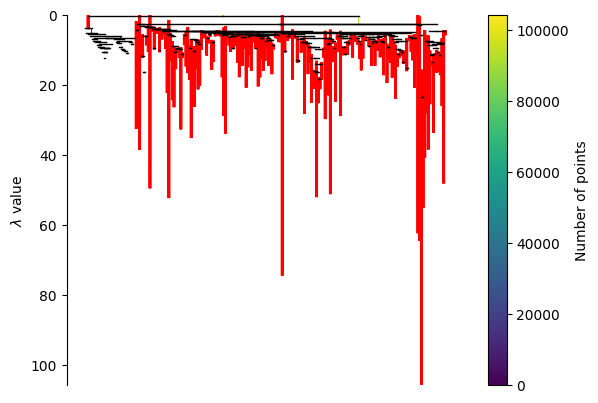

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

clusterer.condensed_tree_.plot(select_clusters=True, 
                               selection_palette=sns.color_palette())
plt.show()

# Agglomerative clustering

- Scipy docs for `Agglomerative Clustering`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

In [136]:
from sklearn.cluster import Birch, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

In [187]:
%%time

# First reduce to manageable subclusters
birch = Birch(
    n_clusters=None,
    threshold=0.07, # 0.15
    branching_factor=50
)

birch.fit(xb_spatial_low)
print(f"Reduced to {len(birch.subcluster_centers_)} subclusters")

Reduced to 34507 subclusters
CPU times: user 13.2 s, sys: 147 ms, total: 13.4 s
Wall time: 3.56 s


In [221]:
%%time

agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.00075,    # max cut distance for the top level
    linkage='average',
    metric='cosine',
    compute_full_tree=True,
    
)

agg.fit(birch.subcluster_centers_)

print(f'Computed {np.unique(agg.labels_).size} clusters.')

Computed 503 clusters.
CPU times: user 11.7 s, sys: 2.52 s, total: 14.2 s
Wall time: 15.8 s


In [222]:
raw_labels = agg.labels_[ birch.labels_ ]

In [223]:
pd.Series(raw_labels).value_counts().sample(10)

71     206
113    203
501      1
497     50
174    338
483    102
305    141
487      5
382     34
58     205
Name: count, dtype: int64

In [224]:
clustered = (
    queries
    .loc[spatial_idx]
    .assign(
        cluster=raw_labels
    )
    .set_index('query_id')
)

In [225]:
def explore_cluster(x):
    print('\n\n'.join(
        clustered.query(f'cluster == {x}').sample(10).query_text.tolist()
    ))

In [235]:
explore_cluster(8)

when is summer solstice for usa

what date is today 25/April in new zealand

what are the main holidays of munich germany

is catherine back on hawaii 5-0 2015

what to do in yellowknife in september

when do the northern lights appear in iceland?

edmonton longest date

what is the time zone in melbourne victoria australia

what events california have for earth day

what month is luau


In [ ]:
clustered.to_excel('output/testing.xlsx')

In [101]:
# children_: pairs of cluster indices merged at each step
# distances_: the distance between each merged pair
children = agg.children_
distances = agg.distances_

# reconstruct a linkage‐style matrix:
n = len(birch.subcluster_centers_)
# i,j,k = children[k] merge at distances[k], forming cluster n+k
linkage_matrix = np.column_stack([
    children,
    distances,
    np.zeros(children.shape[0], dtype=int)  # you can fill in counts if you want
])

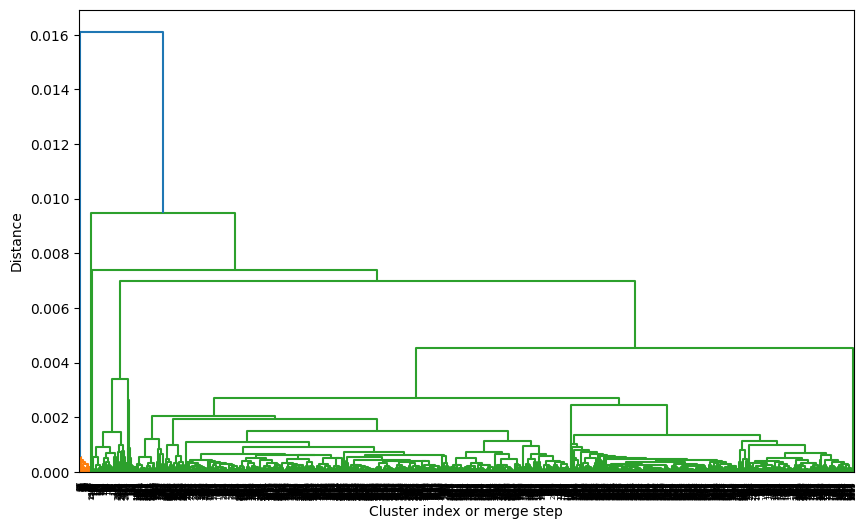

In [106]:
plt.figure(figsize=(10, 6))
hierarchy.dendrogram(linkage_matrix)
plt.xlabel('Cluster index or merge step')
plt.ylabel('Distance')
plt.show()

In [55]:
from scipy.cluster.hierarchy import fcluster

thresholds = [0.5, 0.2, 0.05]

level_labels = {
  t: fcluster(linkage_matrix, t=t, criterion="distance")
  for t in thresholds
}
# each level_labels[t] is size n_subclusters

In [56]:
point_labels_t = level_labels[t][ birch.labels_ ]
# Or for all thresholds, build a “path code”:
paths = np.stack([ level_labels[t][ birch.labels_ ] for t in thresholds ], axis=1)
# paths[j] might look like [4,2,17] for point j → L1=4, L2=2, L3=17


NameError: name 't' is not defined

In [ ]:
%%time

# Build full hierarchy - TODO revert to full
linkage_matrix = linkage(xb_spatial_low, method='average', metric='cosine')

In [46]:
# Visualize the dendrogram
#plt.figure(figsize=(15, 8))
#dendrogram(linkage_matrix, truncate_mode='level', p=10)
#plt.show()

In [40]:
# Cut at different levels to get different granularities
labels_coarse = fcluster(linkage_matrix, t=0.7, criterion='distance')
labels_fine = fcluster(linkage_matrix, t=0.001, criterion='distance')

In [35]:
labels_fine

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [41]:

# Or specify number of clusters
labels_k = fcluster(linkage_matrix, t=50, criterion='maxclust')

In [42]:
labels_coarse.shape

(5000,)

In [43]:
zzz = queries.loc[spatial_idx].head(5000).assign(
    cluster = labels_fine
)

In [44]:
zzz.cluster.value_counts()

cluster
15    1026
1      997
3      650
17     513
4      380
11     309
12     245
5      221
14     151
9      115
13     115
7       97
8       83
10      55
16      31
6        9
2        2
18       1
Name: count, dtype: int64

## Use HDBSCAN

In [48]:
import hdbscan
from hdbscan import plots
import matplotlib.pyplot as plt

In [70]:
%%time

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    metric='euclidean',     # since UMAP output is Euclidean
    cluster_selection_method='leaf'
)

labels = clusterer.fit_predict(xb_spatial_low)

CPU times: user 3.27 s, sys: 459 ms, total: 3.73 s
Wall time: 10 s


In [71]:
tree = clusterer.condensed_tree_.to_pandas()

In [72]:
print("Hierarchy nodes:", len(set(tree['parent']).union(tree['child'])))

Hierarchy nodes: 143042


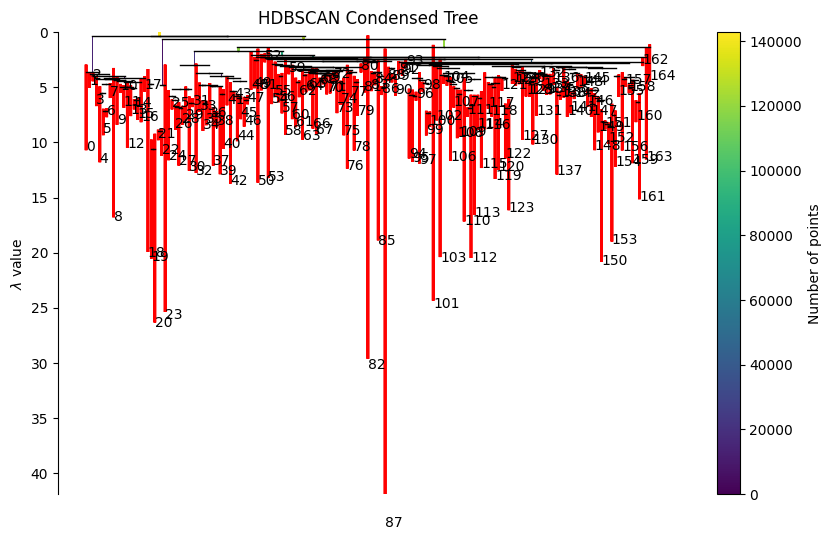

In [73]:
clusterer.condensed_tree_.plot(   # not in hdbscan.plots, but on this object
    leaf_separation=1,            # spacing of leaves
    log_size=False,               # linear bar widths (num points)
    select_clusters=True,         # highlight final clusters
    label_clusters=True           # label them
)
plt.gcf().set_size_inches(10, 6)
plt.title("HDBSCAN Condensed Tree")
plt.show()

In [79]:
tree.parent.value_counts()#.tail(50)

parent
142735    6475
142799    4231
142724    3761
142827    3323
142726    2745
          ... 
142882       6
142929       3
142755       3
142715       2
142713       2
Name: count, Length: 329, dtype: int64

In [76]:
tree.merge(
    queries.loc[spatial_idx].reset_index(),
    left_on='child',
    right_index=True
).set_index('query_id').to_excel('output/testing.xlsx')